In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from vollab.data.filter import filter_chain
from vollab.utils.implied_vol import implied_vol

In [2]:
df = pd.read_csv("../data/sample/spy_chain_2026-08-26.csv")
print(f"Raw: {len(df)} rows")

df = filter_chain(df)
print(f"After filter_chain: {len(df)} rows")
print(f"Spot: ${df['spot'].iloc[0]:.2f}, T: {df['T'].iloc[0]:.4f} yr, Expiry: {df['expiry'].iloc[0]}")
print(f"Calls: {(df['type'] == 'C').sum()}, Puts: {(df['type'] == 'P').sum()}")

Raw: 179 rows
After filter_chain: 102 rows
Spot: $766.08, T: 0.0162 yr, Expiry: 2026-09-02
Calls: 43, Puts: 59


In [3]:
df["iv"] = df.apply(
    lambda row: implied_vol(
        price=row["mid"],
        S=row["spot"],
        K=row["strike"],
        T=row["T"],
        r=row["risk_free_rate"],
        option_type=row["type"],
    ),
    axis=1,
)

valid = df["iv"].notna().sum()
print(f"Valid IVs: {valid} / {len(df)}  ({len(df) - valid} returned NaN)")

Valid IVs: 102 / 102  (0 returned NaN)


OTM calls: 21
OTM puts: 45
    strike        iv
22   767.0  0.136416
23   768.0  0.134698
24   769.0  0.132168
25   770.0  0.130224
26   771.0  0.128058
27   772.0  0.126195
28   773.0  0.124219
29   774.0  0.122575
30   775.0  0.120511
31   776.0  0.119196


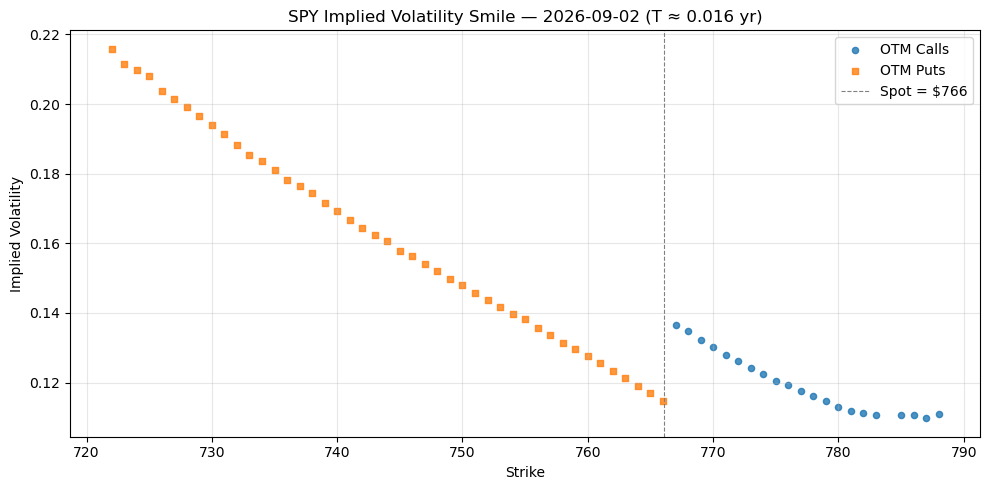

In [4]:
spot = df["spot"].iloc[0]
otm_calls = df[(df["type"] == "C") & (df["strike"] >= spot) & df["iv"].notna()]
otm_puts = df[(df["type"] == "P") & (df["strike"] <= spot) & df["iv"].notna()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(otm_calls["strike"], otm_calls["iv"], marker="o", s=20, label="OTM Calls", alpha=0.8)
ax.scatter(otm_puts["strike"], otm_puts["iv"], marker="s", s=20, label="OTM Puts", alpha=0.8)
ax.axvline(spot, color="gray", linestyle="--", linewidth=0.8, label=f"Spot = ${spot:.0f}")

ax.set_xlabel("Strike")
ax.set_ylabel("Implied Volatility")
ax.set_title(f"SPY Implied Volatility Smile — {df['expiry'].iloc[0]} (T ≈ {df['T'].iloc[0]:.3f} yr)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
print(f"OTM calls: {len(otm_calls)}")
print(f"OTM puts: {len(otm_puts)}")
print(otm_calls[["strike","iv"]].head(10))
plt.show()